# Vueling Fleet & CO2 Forecast: 2026–2035

This notebook extends the historical Vueling aggregated dataset (Feb 2025 – Jan 2026) with a 10-year forecast.

### Key assumptions
| Parameter | Value |
|---|---|
| Passengers 2025 | 40 million |
| Passengers 2035 | 60 million |
| Pax CAGR | `(60/40)^(1/10) - 1 ≈ 4.14%` |
| Fleet 2025 | 140 aircraft |
| Fleet 2035 | 202 aircraft (+62 net) |
| Boeing 737-8 MAX added | 150 total (linear-loaded) |
| Old aircraft retired | 88 total (A-319 first, then A-320) |
| Boeing 737-8 MAX CO2 efficiency | Same as A320Neo |
| CO2 per flight (existing types) | Flat (2025 historical average) |
| Forecast granularity | One row per year_month × aircraft_type |

In [1]:
import pandas as pd
import numpy as np

# ── 0. LOAD YOUR DATA ────────────────────────────────────────────────────────)
df = pd.read_csv("../0. Data/1 Year Flight Data/fr24_vueling_emissions_feb25-feb26.csv")
df['year'] = pd.to_datetime(df['DATE']).dt.year
df['year_month'] = pd.to_datetime(df['DATE']).dt.to_period('M')

df_agg = df.groupby(["year_month", "aircraft_type_icao"], as_index=False)[
    ["aircraft_type_icao", "LTO_CO2_kg", "CCD_CO2_kg", "Total_CO2_kg", "total_distance_km"]
].agg(
    flights_count=("aircraft_type_icao", "count"),
    total_distance_km_sum=("total_distance_km", "sum"),
    LTO_CO2_sum=("LTO_CO2_kg", "sum"),
    CCD_CO2_sum=("CCD_CO2_kg", "sum"),
    Total_CO2_sum=("Total_CO2_kg", "sum"),
)

# Ensure year_month is a Period or string in 'YYYY-MM' format
df_agg['year_month'] = df_agg['year_month'].astype(str).str[:7]

# drop the historical of february 2025 (last month)
df_agg = df_agg[df_agg['year_month'] != '2026-02']

print(f"Historical rows: {len(df_agg)}")
print(f"Aircraft types: {sorted(df_agg['aircraft_type_icao'].unique())}")
df_agg.head()

Historical rows: 57
Aircraft types: ['A319', 'A320', 'A320Neo', 'A321', 'A321Neo']


,year_month,aircraft_type_icao,flights_count,total_distance_km_sum,LTO_CO2_sum,CCD_CO2_sum,Total_CO2_sum
0,2025-02,A319,879,749683.97,1907219.04,7189037.60,9.096257e+06
1,2025-02,A320,9564,9481592.18,24588374.52,92287951.23,1.168763e+08
2,2025-02,A320Neo,1181,1352121.03,2580827.49,10960397.70,1.354123e+07
3,2025-02,A321,2274,2407445.48,6719465.34,28919129.27,3.563859e+07
4,2025-03,A319,1082,913903.93,2347680.32,8794940.83,1.114262e+07


In [2]:
# ── 1. GROWTH & FLEET PARAMETERS ─────────────────────────────────────────────

PAX_2025       = 40_000_000
PAX_2035       = 60_000_000
FLEET_2025     = 140
FLEET_2035     = 202          # net +62
BOEING_TOTAL   = 150           # total B737-8 MAX deliveries over 10 years
RETIREMENTS    = BOEING_TOTAL - (FLEET_2035 - FLEET_2025)  # = 88

PAX_CAGR = (PAX_2035 / PAX_2025) ** (1/10) - 1
print(f"Pax CAGR:        {PAX_CAGR:.4%}")
print(f"Total retirements: {RETIREMENTS}")
print(f"Net fleet additions: {FLEET_2035 - FLEET_2025}")

Pax CAGR:        4.1380%
Total retirements: 88
Net fleet additions: 62


In [3]:
# ── 2. BACK-LOADED BOEING DELIVERY SCHEDULE ───────────────────────────────────
# Years 2026-2035 (10 years). Back-loaded: deliveries ramp up over time.
# We use a quadratic ramp so that later years receive more aircraft.

forecast_years = list(range(2026, 2036))  # 2026 … 2035

# Linear weights: weight[i] = (i+1), normalised to sum to BOEING_TOTAL
raw_weights = np.array([3, 16, 16, 15, 17, 17, 17, 17, 16, 16], dtype=float)
raw_weights /= raw_weights.sum()
boeing_deliveries_per_year = np.round(raw_weights * BOEING_TOTAL).astype(int)

# Adjust rounding error on the last year
boeing_deliveries_per_year[-1] -= boeing_deliveries_per_year.sum() - BOEING_TOTAL

delivery_schedule = pd.Series(boeing_deliveries_per_year, index=forecast_years, name='boeing_deliveries')
print("Boeing 737-8 MAX deliveries per year (back-loaded):")
print(delivery_schedule)
print(f"Total: {delivery_schedule.sum()}")

Boeing 737-8 MAX deliveries per year (back-loaded):
2026     3
2027    16
2028    16
2029    15
2030    17
2031    17
2032    17
2033    17
2034    16
2035    16
Name: boeing_deliveries, dtype: int64
Total: 150


In [4]:
# ── 3. RETIREMENT SCHEDULE (A-319 first, then A-320) ─────────────────────────
# Retire 10 aircraft total, spread proportionally to Boeing deliveries
# (i.e., each Boeing replaces one old aircraft until retirements are exhausted).

# Retirement weight: same shape as deliveries but capped at RETIREMENTS
retire_raw = np.array([3, 16, 12, 3, 1, 10, 3, 8, 16, 16])
retire_raw[-1] += RETIREMENTS - retire_raw.sum()
retirement_schedule = pd.Series(retire_raw, index=forecast_years, name='retirements')

print("Retirements per year:")
print(retirement_schedule)
print(f"Total retirements: {retirement_schedule.sum()}")

Retirements per year:
2026     3
2027    16
2028    12
2029     3
2030     1
2031    10
2032     3
2033     8
2034    16
2035    16
Name: retirements, dtype: int64
Total retirements: 88


In [5]:
# ── 4. INFER 2025 FLEET COMPOSITION FROM HISTORICAL DATA ─────────────────────
# We use annual flights per aircraft type as a proxy for fleet share,
# then scale so that total aircraft = FLEET_2025.

# # Sum flights over the 12-month historical window per aircraft type
# flights_by_type = df_agg.groupby('aircraft_type_icao')['flights_count'].sum()

# # Flights per aircraft are proportional to fleet share
# fleet_share = flights_by_type / flights_by_type.sum()
# fleet_2025 = (fleet_share * FLEET_2025).round().astype(int)

# # Fix rounding so it sums exactly to FLEET_2025
# diff = FLEET_2025 - fleet_2025.sum()
# if diff != 0:
#     largest = fleet_2025.idxmax()
#     fleet_2025[largest] += diff

# print("Inferred 2025 fleet composition:")
# print(fleet_2025.to_frame('aircraft_count'))
# print(f"Total: {fleet_2025.sum()}")

# Actual Fleet 2025 (known) header '2025'
fleet_2025 = pd.Series({
    'A320Neo': 20,
    'A321Neo': 4,
    'A319': 6,
    'A320': 92,
    'A321': 18
}, name='2025')

# Identify old aircraft (non-Neo, non-Boeing) — retirement candidates
OLD_TYPES_ORDER = ['A319', 'A320']   # retire A-319 first
old_types_present = [t for t in OLD_TYPES_ORDER if t in fleet_2025.index]

In [6]:
# ── 5. COMPUTE CO2-PER-FLIGHT AND DISTANCE-PER-FLIGHT BENCHMARKS ──────────────

co2_per_flight = (
    df_agg.groupby('aircraft_type_icao')
    .apply(lambda g: pd.Series({
        'LTO_CO2_per_flight':   g['LTO_CO2_sum'].sum() / g['flights_count'].sum(),
        'CCD_CO2_per_flight':   g['CCD_CO2_sum'].sum() / g['flights_count'].sum(),
        'Total_CO2_per_flight': g['Total_CO2_sum'].sum() / g['flights_count'].sum(),
    }))
)

dist_per_flight = (
    df_agg.groupby('aircraft_type_icao')
    .apply(lambda g: g['total_distance_km_sum'].sum() / g['flights_count'].sum())
    .rename('dist_per_flight')
)

# Boeing 737-8 MAX efficiency = A320Neo
co2_per_flight.loc['B38M'] = co2_per_flight.loc['A320Neo']
dist_per_flight['B38M']    = dist_per_flight['A320Neo']

print("CO2 per flight (kg):") 
print(co2_per_flight.round(1))
print("\nDistance per flight (km):")
print(dist_per_flight.round(1))

CO2 per flight (kg):
                    LTO_CO2_per_flight  CCD_CO2_per_flight  \
aircraft_type_icao                                           
A319                            2169.8              8464.6   
A320                            2570.9             10006.8   
A320Neo                         2185.3              9108.0   
A321                            2954.9             12057.9   
A321Neo                         2511.7             11314.4   
B38M                            2185.3              9108.0   

                    Total_CO2_per_flight  
aircraft_type_icao                        
A319                             10634.4  
A320                             12577.7  
A320Neo                          11293.2  
A321                             15012.8  
A321Neo                          13826.1  
B38M                             11293.2  

Distance per flight (km):
aircraft_type_icao
A319        886.0
A320       1034.0
A320Neo    1120.5
A321        997.6
A321Neo    1118.5
B3

/var/folders/qq/m6bmnsqd617gjhfgc8tzfbhh0000gn/T/ipykernel_11489/137130985.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/qq/m6bmnsqd617gjhfgc8tzfbhh0000gn/T/ipykernel_11489/137130985.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['total_distance_km_sum'].sum() / g['flights_count'].sum())


In [7]:
# ── 6. COMPUTE MONTHLY FLIGHTS PER AIRCRAFT FROM HISTORICAL DATA ──────────────
# Average monthly flights per aircraft, per type (utilisation proxy)

# months each type appears in historical data
months_per_type = df_agg.groupby('aircraft_type_icao')['year_month'].nunique()
total_flights_per_type = df_agg.groupby('aircraft_type_icao')['flights_count'].sum()

# monthly flights per aircraft = total flights / (months present * aircraft count)
monthly_flights_per_ac = (
    total_flights_per_type / (months_per_type * fleet_2025)
).rename('monthly_flights_per_ac')

# Boeing uses same utilisation as A320Neo
monthly_flights_per_ac['B38M'] = monthly_flights_per_ac['A320Neo']

print("Monthly flights per aircraft by type:")
print(monthly_flights_per_ac.round(1))

Monthly flights per aircraft by type:
aircraft_type_icao
A319       167.5
A320       142.1
A320Neo     64.3
A321       153.6
A321Neo     69.8
B38M        64.3
Name: monthly_flights_per_ac, dtype: float64


In [8]:
# ── 7. SEASONAL PROFILE FROM HISTORICAL DATA ──────────────────────────────────
# Compute month-of-year share of annual flights (averaged across all types)

df_agg['month'] = df_agg['year_month'].str[5:7].astype(int)
monthly_total = df_agg.groupby('month')['flights_count'].sum()
seasonal_share = monthly_total / monthly_total.sum()  # sums to 1.0

print("Seasonal share of annual flights by month:")
print(seasonal_share.round(4))

Seasonal share of annual flights by month:
month
1     0.0663
2     0.0631
3     0.0786
4     0.0833
5     0.0901
6     0.0922
7     0.0984
8     0.0995
9     0.0915
10    0.0887
11    0.0723
12    0.0760
Name: flights_count, dtype: float64


In [9]:
# ── 8. BUILD FLEET COMPOSITION YEAR BY YEAR ───────────────────────────────────

fleet_by_year = {}   # {year: Series(aircraft_type -> count)}
current_fleet = fleet_2025.copy().astype(float)

# Cumulative retirements tracker per old type
retire_pool = {t: int(current_fleet.get(t, 0)) for t in old_types_present}

for year in forecast_years:
    deliveries  = int(delivery_schedule[year])
    retirements = int(retirement_schedule[year])

    # Add Boeing
    current_fleet['B38M'] = current_fleet.get('B38M', 0) + deliveries

    # Retire old aircraft: A319 first, then A320
    remaining_retirements = retirements
    for old_type in old_types_present:
        if remaining_retirements <= 0:
            break
        can_retire = min(int(current_fleet.get(old_type, 0)), remaining_retirements)
        current_fleet[old_type] = current_fleet.get(old_type, 0) - can_retire
        remaining_retirements -= can_retire

    # Drop zeroed-out types
    fleet_by_year[year] = current_fleet[current_fleet > 0].copy()

# Display fleet evolution
fleet_by_year['2025'] = fleet_2025  # add initial year for completeness 
fleet_evolution = pd.DataFrame(fleet_by_year).T.fillna(0).astype(int)
fleet_evolution['TOTAL'] = fleet_evolution.sum(axis=1)
fleet_evolution.to_csv('../0. Data/fleet_evolution.csv')
print("Fleet composition by year:")
fleet_evolution


Fleet composition by year:


,A319,A320,A320Neo,A321,A321Neo,B38M,TOTAL
2026,3,92,20,18,4,3,140
2027,0,79,20,18,4,19,140
2028,0,67,20,18,4,35,144
2029,0,64,20,18,4,50,156
2030,0,63,20,18,4,67,172
2031,0,53,20,18,4,84,179
2032,0,50,20,18,4,101,193
2033,0,42,20,18,4,118,202
2034,0,26,20,18,4,134,202
2035,0,10,20,18,4,150,202


In [10]:
# ── 9. GENERATE FORECAST ROWS ─────────────────────────────────────────────────
# Logic: derive target flights per year from pax target, then distribute
# across aircraft types proportionally to fleet share and utilisation,
# and across months by seasonal profile.
#
# This guarantees the forecast hits 60M pax in 2035 by construction.

LOAD_FACTOR = 0.9   # assumed constant seat load factor

SEATS = {
    'A319': 144, 'A320': 186, 'A321': 228,
    'A320Neo': 186, 'A321Neo': 236, 'B38M': 200
}

forecast_rows = []

for year in forecast_years:
    fleet_year = fleet_by_year[year]

    # ── Target pax and flights for this year ──────────────────────────────────
    target_pax = PAX_2025 * (1 + PAX_CAGR) ** (year - 2025)

    # Weighted average seats across fleet this year
    total_ac   = fleet_year.sum()
    avg_seats  = sum(
        SEATS.get(ac, 180) * count / total_ac
        for ac, count in fleet_year.items()
    )

    # Total flights needed to carry target_pax at given load factor & seat config
    target_flights_year = target_pax / (avg_seats * LOAD_FACTOR)

    # ── Distribute flights across aircraft types by utilisation-weighted share ─
    # Utilisation weight = monthly_flights_per_ac × fleet count for each type
    util_weights = {
        ac: monthly_flights_per_ac.get(ac, monthly_flights_per_ac.mean()) * count
        for ac, count in fleet_year.items()
        if count > 0
    }
    total_util = sum(util_weights.values())

    for month in range(1, 13):
        ym        = f"{year}-{month:02d}"
        season_wt = float(seasonal_share.get(month, 1/12))

        for ac_type, ac_count in fleet_year.items():
            if ac_count == 0:
                continue

            # Flights = annual target × type share × seasonal weight
            type_share = util_weights[ac_type] / total_util
            flights    = target_flights_year * type_share * (season_wt * 12) / 12

            # CO2 — flat per-flight rates from historical benchmarks
            lto   = co2_per_flight.loc[ac_type, 'LTO_CO2_per_flight']   * flights
            ccd   = co2_per_flight.loc[ac_type, 'CCD_CO2_per_flight']   * flights
            total = co2_per_flight.loc[ac_type, 'Total_CO2_per_flight'] * flights

            # Distance — flat avg km/flight from historical benchmarks
            dist  = dist_per_flight.get(ac_type, dist_per_flight.mean()) * flights

            # inside the ac_type loop, after computing flights
            pax = flights * SEATS.get(ac_type, 180) * LOAD_FACTOR

            forecast_rows.append({
                'year_month':            ym,
                'aircraft_type_icao':    ac_type,
                'flights_count':         round(flights, 2),
                'total_distance_km_sum': round(dist,    2),
                'LTO_CO2_sum':           round(lto,     2),
                'CCD_CO2_sum':           round(ccd,     2),
                'Total_CO2_sum':         round(total,   2),
                'pax':                   round(pax,     0),
            })

df_forecast = pd.DataFrame(forecast_rows)

df_agg['pax'] = (
    df_agg['flights_count']
    * df_agg['aircraft_type_icao'].map(SEATS).fillna(180)
    * LOAD_FACTOR
).round(0)

# ── Sanity check: implied pax per year ────────────────────────────────────────
df_forecast['year'] = df_forecast['year_month'].str[:4].astype(int)
check = df_forecast.groupby('year').apply(lambda g: (
    g['flights_count'].sum() * LOAD_FACTOR *
    g['aircraft_type_icao'].map(SEATS).fillna(180).mul(
        g['flights_count'] / g['flights_count'].sum()
    ).sum()
) / 1e6).rename('implied_pax_M')
print("Implied passengers (M) by year:")
print(check.round(2))
print(f"\nForecast rows generated: {len(df_forecast)}")
df_forecast = df_forecast.drop(columns='year')
df_forecast.head(12)

Implied passengers (M) by year:
year
2026    41.64
2027    43.39
2028    45.17
2029    47.02
2030    48.94
2031    51.02
2032    53.14
2033    55.41
2034    57.92
2035    60.62
Name: implied_pax_M, dtype: float64

Forecast rows generated: 612


/var/folders/qq/m6bmnsqd617gjhfgc8tzfbhh0000gn/T/ipykernel_11489/2246266265.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  check = df_forecast.groupby('year').apply(lambda g: (


,year_month,aircraft_type_icao,flights_count,total_distance_km_sum,LTO_CO2_sum,CCD_CO2_sum,Total_CO2_sum,pax
0,2026-01,A320Neo,1133.22,1269722.26,2476416.71,1.032132e+07,1.279774e+07,189701.0
1,2026-01,A321Neo,246.05,275214.17,617991.17,2.783886e+06,3.401878e+06,52261.0
2,2026-01,A319,443.01,392487.16,961227.84,3.749926e+06,4.711154e+06,57414.0
3,2026-01,A320,11527.10,11919273.24,29635379.80,1.153495e+08,1.449849e+08,1929637.0
4,2026-01,A321,2436.80,2430999.34,7200524.66,2.938272e+07,3.658325e+07,500031.0
5,2026-01,B38M,169.98,190458.34,371462.51,1.548198e+06,1.919661e+06,30597.0
6,2026-02,A320Neo,1079.84,1209914.29,2359769.58,9.835155e+06,1.219493e+07,180766.0
7,2026-02,A321Neo,234.46,262250.70,588881.82,2.652756e+06,3.241639e+06,49799.0
8,2026-02,A319,422.14,373999.76,915950.94,3.573292e+06,4.489243e+06,54710.0
9,2026-02,A320,10984.14,11357837.47,28239458.93,1.099162e+08,1.381556e+08,1838745.0


In [11]:
# ── Sanity check: daily flights per aircraft by year ──────────────────────────

flights_2025 = df_agg['flights_count'].sum()
aircraft_2025 = FLEET_2025

print("── 2025 (historical) ────────────────────────────────────────────")
print(f"  Total flights        : {flights_2025:,.0f}")
print(f"  Fleet size           : {aircraft_2025}")
print(f"  Flights/ac/year      : {flights_2025/aircraft_2025:.1f}")
print(f"  Flights/ac/day       : {flights_2025/aircraft_2025/365:.2f}\n")

df_forecast['year'] = df_forecast['year_month'].str[:4].astype(int)

annual_flights = df_forecast.groupby('year')['flights_count'].sum()

sanity = pd.DataFrame({
    'total_flights'     : annual_flights,
    'total_aircraft'    : pd.Series({y: fleet_by_year[y].sum() for y in forecast_years}),
    'target_pax_M'      : pd.Series({y: PAX_2025 * (1 + PAX_CAGR)**(y-2025) / 1e6
                                      for y in forecast_years}),
})

sanity['flights_per_ac_per_day'] = sanity['total_flights'] / sanity['total_aircraft'] / 365
sanity['flights_per_ac_per_year'] = sanity['total_flights'] / sanity['total_aircraft']

print(sanity.round(2).to_string())
print()
print("── Industry benchmarks ──────────────────────────────────────────")
print("  Typical short-haul utilisation : 4–6 flights/aircraft/day")
print("  High utilisation (Ryanair etc.) : up to 8–9 flights/aircraft/day")
print("  Low utilisation / flag carrier  : ~3 flights/aircraft/day")

── 2025 (historical) ────────────────────────────────────────────
  Total flights        : 220,083
  Fleet size           : 140
  Flights/ac/year      : 1572.0
  Flights/ac/day       : 4.31

      total_flights  total_aircraft  target_pax_M  flights_per_ac_per_day  flights_per_ac_per_year
2026      240773.47           140.0         41.66                    4.71                  1719.81
2027      247517.56           140.0         43.38                    4.84                  1767.98
2028      256033.32           144.0         45.17                    4.87                  1778.01
2029      265849.85           156.0         47.04                    4.67                  1704.17
2030      276293.88           172.0         48.99                    4.40                  1606.36
2031      286419.92           179.0         51.02                    4.38                  1600.11
2032      297716.49           193.0         53.13                    4.23                  1542.57
2033      309052.

In [12]:
sanity.round(2).to_csv('../0. Data/sanity_check_150_new_boeing.csv')

In [13]:
# ── 10. COMBINE HISTORICAL + FORECAST ─────────────────────────────────────────

df_agg['origin'] = 'historical'
df_forecast['origin'] = 'forecast'

# Remove january 2026 (first month) to avoid overlap with historical data
df_forecast = df_forecast[df_forecast['year_month'] != '2026-01']
df_combined = pd.concat([df_agg.drop(columns=['month'], errors='ignore'),
                          df_forecast], ignore_index=True)
df_combined['year_month'] = df_combined['year_month'].astype(str).str[:7]
df_combined = df_combined.sort_values(['year_month', 'aircraft_type_icao']).reset_index(drop=True)

print(f"Combined dataset: {len(df_combined)} rows")
print(f"Date range: {df_combined['year_month'].min()} → {df_combined['year_month'].max()}")
df_combined.tail(12)

Combined dataset: 663 rows
Date range: 2025-02 → 2035-12


,year_month,aircraft_type_icao,flights_count,total_distance_km_sum,LTO_CO2_sum,CCD_CO2_sum,Total_CO2_sum,pax,origin,year
651,2035-10,A321Neo,533.31,596531.11,1339505.75,6.034118e+06,7.373625e+06,113276.0,forecast,2035.0
652,2035-10,B38M,18422.06,20641074.90,40257546.34,1.677872e+08,2.080448e+08,3315971.0,forecast,2035.0
653,2035-11,A320,2212.32,2287583.82,5687713.84,2.213824e+07,2.782595e+07,370342.0,forecast,2035.0
654,2035-11,A320Neo,2000.92,2241939.05,4372590.36,1.822428e+07,2.259687e+07,334954.0,forecast,2035.0
655,2035-11,A321,4302.64,4292397.26,12713912.25,5.188085e+07,6.459477e+07,882902.0,forecast,2035.0
656,2035-11,A321Neo,434.44,485943.58,1091182.36,4.915487e+06,6.006670e+06,92276.0,forecast,2035.0
657,2035-11,B38M,15006.90,16814542.86,32794427.69,1.366821e+08,1.694765e+08,2701242.0,forecast,2035.0
658,2035-12,A320,2325.25,2404357.45,5978052.91,2.326832e+07,2.924637e+07,389247.0,forecast,2035.0
659,2035-12,A320Neo,2103.06,2356382.66,4595796.71,1.915457e+07,2.375037e+07,352052.0,forecast,2035.0
660,2035-12,A321,4522.28,4511510.01,13362915.63,5.452920e+07,6.789212e+07,927971.0,forecast,2035.0


In [14]:
# ── 11. ANNUAL SUMMARY ────────────────────────────────────────────────────────

df_combined['year'] = df_combined['year_month'].str[:4].astype(int)

annual_summary = df_combined.groupby('year').agg(
    total_flights   = ('flights_count', 'sum'),
    total_CO2_tonnes= ('Total_CO2_sum', lambda x: x.sum() / 1000),  # kg → tonnes
).round(0)

print("Annual summary (historical + forecast):")
annual_summary

Annual summary (historical + forecast):


,total_flights,total_CO2_tonnes
year,,
2025,205498.0,2622306.0
2026,239402.0,3066407.0
2027,247518.0,3170150.0
2028,256033.0,3260690.0
2029,265850.0,3364566.0
2030,276294.0,3473531.0
2031,286420.0,3577512.0
2032,297716.0,3696269.0
2033,309052.0,3812627.0


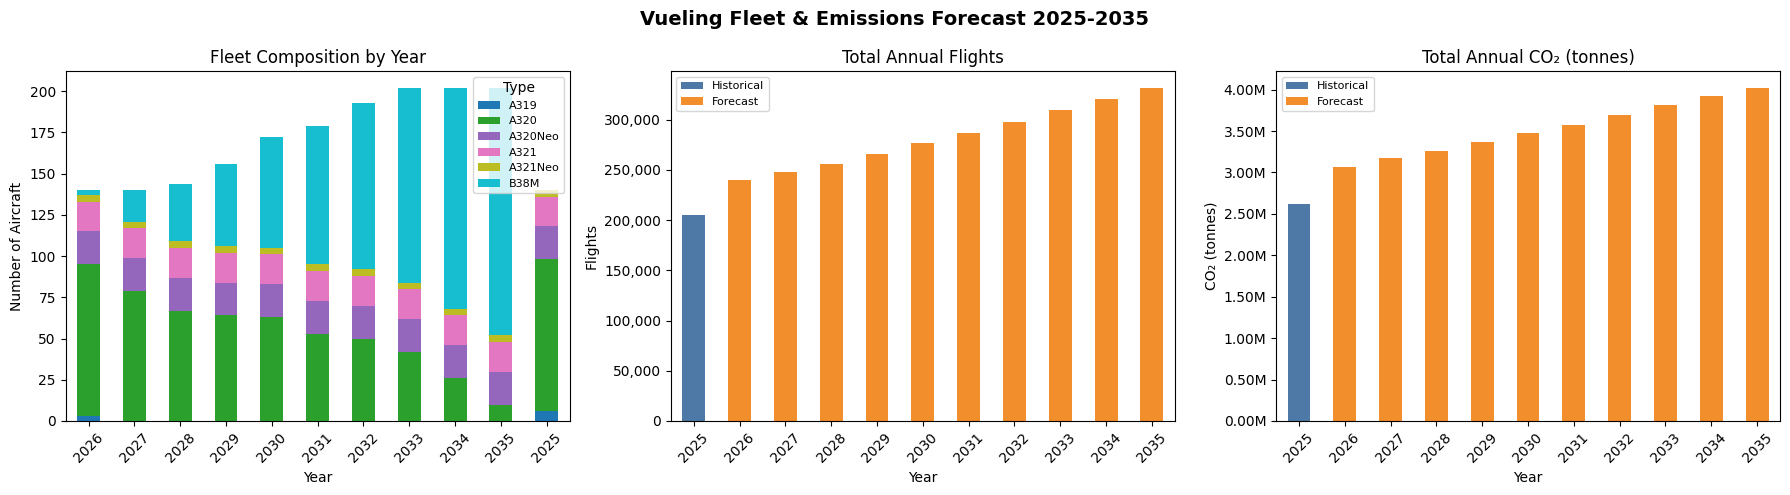

Plot saved as vueling_forecast.png


In [15]:
# ── 12. QUICK VISUALISATION ───────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vueling Fleet & Emissions Forecast 2025-2035', fontsize=14, fontweight='bold')

# -- Fleet composition
ax = axes[0]
fleet_evolution.drop(columns='TOTAL').plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Fleet Composition by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Aircraft')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type', fontsize=8)

# -- Annual flights
ax = axes[1]
colors = ['#4e79a7' if y <= 2025 else '#f28e2b' for y in annual_summary.index]
annual_summary['total_flights'].plot(kind='bar', ax=ax, color=colors)
ax.set_title('Total Annual Flights')
ax.set_xlabel('Year')
ax.set_ylabel('Flights')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)

# -- Annual CO2
ax = axes[2]
annual_summary['total_CO2_tonnes'].plot(kind='bar', ax=ax, color=colors)
ax.set_title('Total Annual CO₂ (tonnes)')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (tonnes)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.tick_params(axis='x', rotation=45)

# Legend patch for historical vs forecast
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4e79a7', label='Historical'),
                   Patch(facecolor='#f28e2b', label='Forecast')]
for ax in axes[1:]:
    ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig('vueling_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as vueling_forecast.png")

In [18]:
# ── 13. EXPORT ────────────────────────────────────────────────────────────────

df_combined.to_csv('../0. Data/1 Year Flight Data/vueling_historical_and_forecast.csv', index=False)
# df_forecast.to_csv('0. Data/ 1 Year Flight Data/vueling_forecast_only.csv', index=False)
print("Exported:")
print("  vueling_historical_and_forecast.csv")
# print("  vueling_forecast_only.csv")

Exported:
  vueling_historical_and_forecast.csv
